In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [19]:
# Create a synthetic dataset
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, n_classes=2, random_state=42)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
X

array([[ 0.55942643,  2.38869353],
       [ 1.31217492, -0.7173148 ],
       [-1.5598485 , -1.92487377],
       [-2.2813861 , -0.1368559 ],
       [ 1.56070438, -0.42795824],
       [-0.80804463,  1.19664076],
       [-0.27062383, -2.25553963],
       [ 0.480502  ,  0.54914434],
       [-1.20757158, -1.26898369],
       [ 0.25415746, -1.79532002],
       [ 2.59123946,  0.24472415],
       [ 0.07123641,  0.49429823],
       [-1.17762637, -1.20592943],
       [ 0.93343952,  0.68811892],
       [ 1.65214494, -0.35885569],
       [-1.40735658, -1.56826626],
       [ 1.02255619, -1.08324727],
       [-0.81680628, -0.6795874 ],
       [ 1.50575249, -0.38919817],
       [-2.17105282, -0.04862909],
       [ 0.71479373, -1.42922002],
       [-0.15013844, -0.11708689],
       [-1.4117586 , -1.5332749 ],
       [-2.58590856, -0.40925706],
       [ 0.82600732, -1.05383855],
       [-0.07133524,  0.08896214],
       [ 0.6273745 , -1.32933233],
       [ 1.65882246, -0.43131517],
       [ 1.2798899 ,

In [21]:
# Initialize the SVM model with a linear kernel
model = SVC(kernel='linear')

# Train the model on the training data
model.fit(X_train, y_train)

SVC(kernel='linear')

In [22]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        14

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



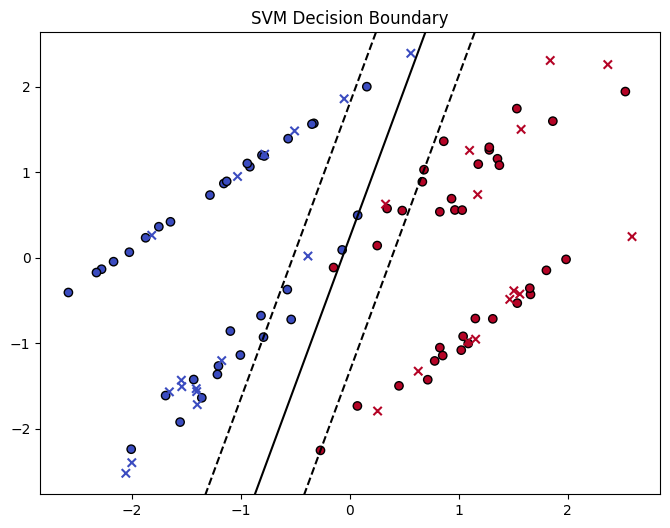

In [25]:
# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', marker='x')

# Get the separating hyperplane
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 30), np.linspace(ylim[0], ylim[1], 30))
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the hyperplane and margins
ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])
plt.title('SVM Decision Boundary')
plt.show()